In [3]:



# Netflix Dataset

## Dataset Understanding

## Data Cleaning

## Exploratory Data Analysis

## Visualizations

## Insights

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
print(os.getlogin())

HP-PC


In [6]:

netflix = pd.read_csv(r"C:\Users\HP-PC\Desktop\internship\netflix_titles.csv")

In [7]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
netflix.shape

(8807, 12)

In [9]:
netflix.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [10]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [11]:
netflix.select_dtypes(include=['int64','float64']).columns

Index(['release_year'], dtype='object')

In [12]:
netflix.select_dtypes(include=['object']).columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [13]:
# show_id

In [14]:
# This dataset contains Netflix movies and TV shows, Show id, type, title, director, cast, country, date added, release year, rating, duration, listed-in and description.

In [15]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [20]:

netflix = netflix.fillna({
    'director': 'Unknown',
    'cast': 'Unknown Role/Cast',
    'country': 'Unknown Country',
    'date_added': 'Not Added',
    'rating': 'NR',         # NR stands for "Not Rated"
    'duration': '0 mins'
})




In [21]:
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [22]:
# Data Cleansing Methodology: Netflix Dataset
# #For the Netflix dataset, missing values in categorical attributes (director, cast, country, date_added, and rating) and numeric/temporal attributes (duration) were handled using a targeted dictionary-based imputation method (.fillna()).

# Preservation of Volume: Deleting rows with missing fields would have eliminated over 3,000 titles, severely reducing the sample size and skewing insights on content trends.

# Contextual Placeholders: Specific, logical placeholders were applied based on the column's data type:

# Textual gaps were filled with "Unknown Country" or "Unknown Role/Cast".

# Missing content ratings were designated as "NR" (Not Rated).

# Missing runtimes were standardized to "0 mins" to maintain consistent text formatting.

# Data Type Consistency: This approach ensures that all columns retain their intended structural format without generating processing errors during subsequent visualization or filtering steps.

In [26]:

duplicates_count = netflix.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")


netflix = netflix.drop_duplicates()


print(f"Duplicates remaining: {netflix.duplicated().sum()}")

Number of duplicate rows found: 0
Duplicates remaining: 0


In [27]:

netflix = pd.read_csv(r"C:\Users\HP-PC\Desktop\internship\netflix_titles.csv")


rows_before = netflix.shape[0]


duplicate_count = netflix.duplicated().sum()


netflix = netflix.drop_duplicates()


rows_after = netflix.shape[0]


print("=== NETFLIX DUPLICATE REMOVAL REPORT ===")
print(f"Number of duplicates found: {duplicate_count}")
print(f"Rows before cleaning:       {rows_before}")
print(f"Rows after cleaning:        {rows_after}")
print(f"Total duplicates removed:   {rows_before - rows_after}")

=== NETFLIX DUPLICATE REMOVAL REPORT ===
Number of duplicates found: 0
Rows before cleaning:       8807
Rows after cleaning:        8807
Total duplicates removed:   0


In [28]:
import numpy as np
import pandas as pd

netflix = pd.read_csv(r"C:\Users\HP-PC\Desktop\internship\netflix_titles.csv")

netflix.columns = netflix.columns.str.strip().str.lower()

netflix["type"] = netflix["type"].str.strip().str.title()
netflix["title"] = netflix["title"].str.strip().str.title()
netflix["rating"] = netflix["rating"].str.strip().str.upper()

netflix["date_added"] = pd.to_datetime(
    netflix["date_added"].str.strip(), errors="coerce"
)

misaligned_mask = netflix["rating"].str.contains(
    "MIN|SEASON", na=False, case=False
)
netflix.loc[misaligned_mask, "duration"] = netflix.loc[
    misaligned_mask, "rating"
]
netflix.loc[misaligned_mask, "rating"] = "NR"

netflix = netflix.fillna(
    {
        "director": "Unknown",
        "cast": "Unknown Role/Cast",
        "country": "Unknown Country",
        "rating": "NR",
        "duration": "Unknown Duration",
    }
)

netflix["date_added"] = netflix["date_added"].fillna(pd.Timestamp("1900-01-01"))

netflix = netflix.drop_duplicates()

print("Netflix data processing complete.")

Netflix data processing complete.


In [29]:
import pandas as pd

netflix_summary = netflix.describe(include="all")
print("=== NETFLIX OVERALL SUMMARY ===")
print(netflix_summary)

type_distribution = netflix["type"].value_counts()
print("\n1. CONTENT TYPE DISTRIBUTION:")
print(type_distribution)

netflix["year_added"] = netflix["date_added"].dt.year
content_by_year = (
    netflix[netflix["year_added"] > 1900]["year_added"]
    .value_counts()
    .sort_index()
)
print("\n2. CONTENT ADDED BY YEAR (TOP 10 RECENT YEARS):")
print(content_by_year.tail(10))

top_countries = netflix["country"].value_counts().head(10)
print("\n3. TOP 10 CONTENT-PRODUCING COUNTRIES:")
print(top_countries)

common_ratings = netflix["rating"].value_counts().head(5)
print("\n4. MOST COMMON RATINGS:")
print(common_ratings)

top_genres = netflix["listed_in"].value_counts().head(10)
print("\n5. TOP 10 GENRES / CATEGORIES:")
print(top_genres)

=== NETFLIX OVERALL SUMMARY ===
       show_id   type                title director               cast  \
count     8807   8807                 8807     8807               8807   
unique    8807      2                 8798     4529               7693   
top         s1  Movie  Fullmetal Alchemist  Unknown  Unknown Role/Cast   
freq         1   6131                    2     2634                825   
mean       NaN    NaN                  NaN      NaN                NaN   
min        NaN    NaN                  NaN      NaN                NaN   
25%        NaN    NaN                  NaN      NaN                NaN   
50%        NaN    NaN                  NaN      NaN                NaN   
75%        NaN    NaN                  NaN      NaN                NaN   
max        NaN    NaN                  NaN      NaN                NaN   
std        NaN    NaN                  NaN      NaN                NaN   

              country                     date_added  release_year rating  \
co

In [30]:
netflix.to_csv(
    r"C:\Users\HP-PC\Desktop\internship\cleaned_netflix_titles.csv",
    index=False,
)

with pd.ExcelWriter(
    r"C:\Users\HP-PC\Desktop\internship\netflix_summary_statistics.xlsx"
) as writer:
    netflix_summary.to_excel(writer, sheet_name="Netflix_Summary")

print("Netflix data and statistical results successfully saved!")

Netflix data and statistical results successfully saved!


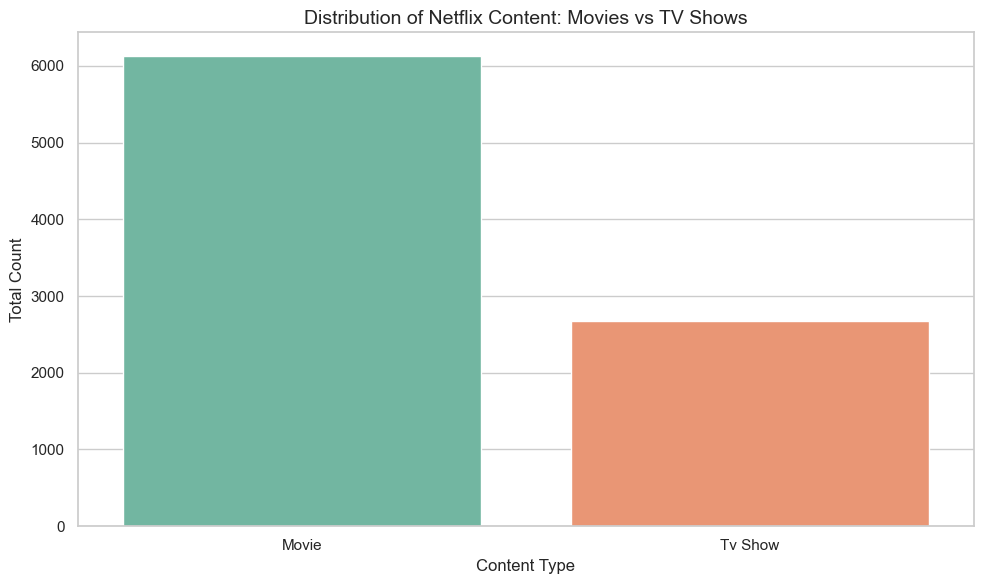

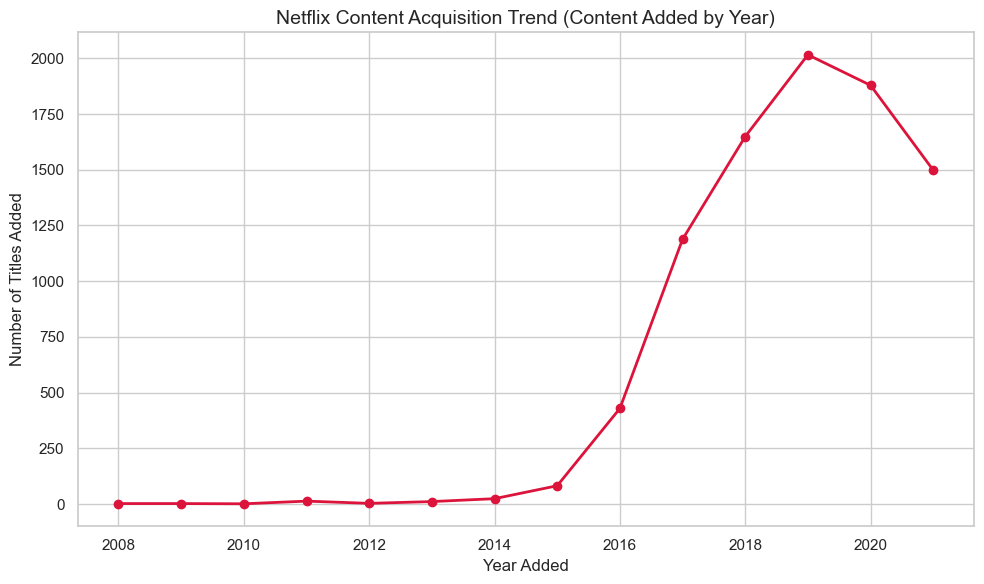

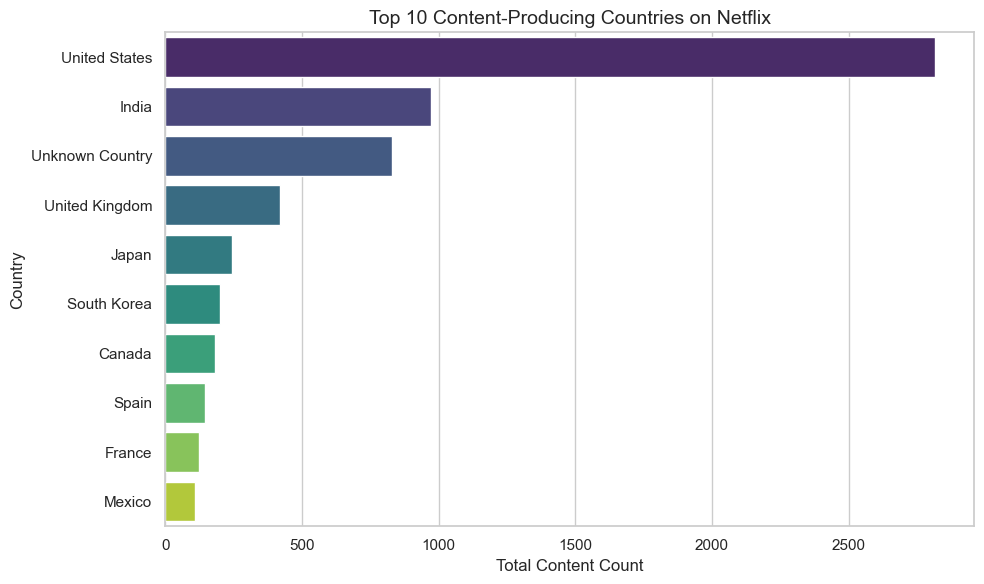

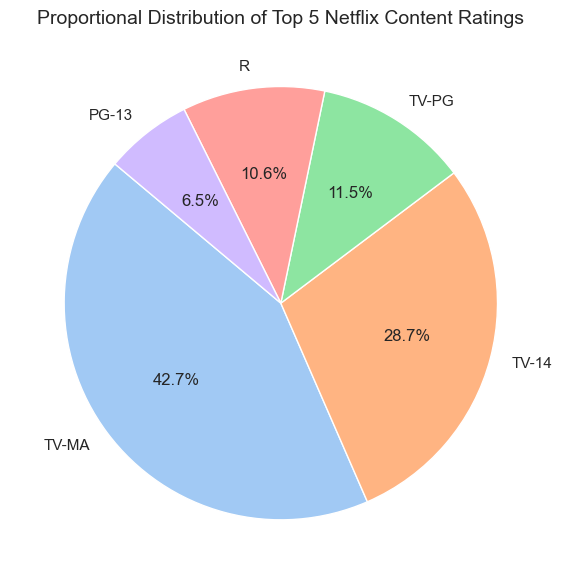

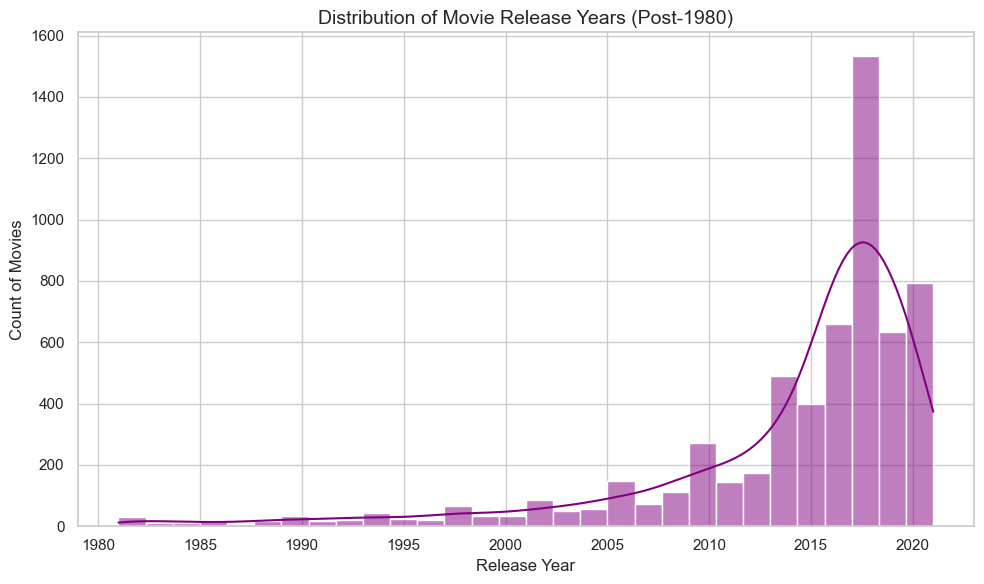

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


plt.figure()
sns.countplot(data=netflix, x="type", hue="type", palette="Set2", legend=False)
plt.title("Distribution of Netflix Content: Movies vs TV Shows", fontsize=14)
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Total Count", fontsize=12)
plt.tight_layout()
plt.savefig("netflix_1_content_distribution.png")
plt.show()


plt.figure()
netflix_valid_dates = netflix[netflix["year_added"] > 1900]
timeline = (
    netflix_valid_dates.groupby("year_added")["show_id"].count().sort_index()
)
plt.plot(
    timeline.index,
    timeline.values,
    marker="o",
    color="crimson",
    linewidth=2,
)
plt.title("Netflix Content Acquisition Trend (Content Added by Year)", fontsize=14)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)
plt.tight_layout()
plt.savefig("netflix_2_timeline_trend.png")
plt.show()


plt.figure()
top_countries_data = netflix["country"].value_counts().head(10)
sns.barplot(
    x=top_countries_data.values,
    y=top_countries_data.index,
    hue=top_countries_data.index,
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Content-Producing Countries on Netflix", fontsize=14)
plt.xlabel("Total Content Count", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.savefig("netflix_3_top_countries.png")
plt.show()


plt.figure()
top_ratings = netflix["rating"].value_counts().head(5)
plt.pie(
    top_ratings.values,
    labels=top_ratings.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
)
plt.title("Proportional Distribution of Top 5 Netflix Content Ratings", fontsize=14)
plt.tight_layout()
plt.savefig("netflix_4_ratings_pie.png")
plt.show()


plt.figure()
movies_only = netflix[
    (netflix["type"] == "Movie") & (netflix["release_year"] > 1980)
]
sns.histplot(
    data=movies_only,
    x="release_year",
    bins=30,
    kde=True,
    color="purple",
)
plt.title("Distribution of Movie Release Years (Post-1980)", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Count of Movies", fontsize=12)
plt.tight_layout()
plt.savefig("netflix_5_release_year_histogram.png")
plt.show()